# Announcement-on-ML
<a href='http://www.kgptalkie.com' target="_blank"> <img src='https://github.com/laxmimerit/Important-Announcement-on-ML/raw/master/kgptalkie_strips.png'/></a>

# ML Resources
|  ML Course | Description |
|:---|:---|
| [**Deploy LLM App with Ollama and Langchain in Production**](https://www.udemy.com/course/ollama-and-langchain/?referralCode=7F4C0C7B8CF223BA9327) | Master Langchain v0.3, Private Chatbot, Deploy LLM App.  Ollama, LLAMA, LLAMA 3.2, FAISS, RAG, Deploy RAG, Gen AI, LLM|
| [**Fine Tuning LLM with HuggingFace Transformers for NLP**](https://www.udemy.com/course/fine-tuning-llm-with-hugging-face-transformers/?referralCode=6DEB3BE17C2644422D8E) | Learn how to fine tune LLM with custom dataset. You will learn basics of transformers then fine tune LLM|
| [**Data Visualization in Python Masterclass™: Beginners to Pro**](https://bit.ly/udemy95off_kgptalkie) |  Learn to build Machine Learning and Deep Learning models using Python and its libraries like Scikit-Learn, Keras, and TensorFlow. |
| [**Python for Machine Learning: A Step-by-Step Guide**](https://bit.ly/ml-ds-project) | Learn to build Machine Learning and Deep Learning models using Python and its libraries like Scikit-Learn, Keras, and TensorFlow. |
| [**Deep Learning for Beginners with Python**](https://bit.ly/dl-with-python) | Neural Networks, TensorFlow, ANN, CNN, RNN, LSTM, Transfer Learning and Much More. |
| [**Python for Linear Regression in Machine Learning**](https://bit.ly/regression-python) | Learn to build Linear Regression models using Python and its libraries like Scikit-Learn. |
| [**Introduction to Spacy 3 for Natural Language Processing**](https://bit.ly/spacy-intro) | Learn to build Natural Language Processing models using Python and its libraries like Spacy. |
| [**Advanced Machine Learning and Deep Learning Projects**](https://bit.ly/kgptalkie_ml_projects) | Learn to build Advanced Machine Learning and Deep Learning models using Python and transformer models like BERT, GPT-2, and XLNet. |
| [**Natural Language Processing in Python for Beginners**](https://bit.ly/intro_nlp) | Learn to build Natural Language Processing Projects using Spacy, NLTK, and Gensim, and transformer models like BERT, GPT-2, and XLNet. |
| [**Deployment of Machine Learning Models in Production in Python**](https://bit.ly/bert_nlp) |  Learn to deploy Machine Learning and Deep Learning models using Python and its libraries like Flask, Streamlit, and NGINX. |
| [**R 4.0 Programming for Data Science - Beginners to Pro**](https://bit.ly/r4-ml) | Learn to build Machine Learning and Deep Learning models using R and its libraries like caret, tidyverse, and keras. |


## Tool Calling or Function Calling
- LLM Automatically calls the function based on the query
- Function parameters are automatically passed to the function
- It is one of the essential requirements of the Agent
- Not all LLM supports tool calling.

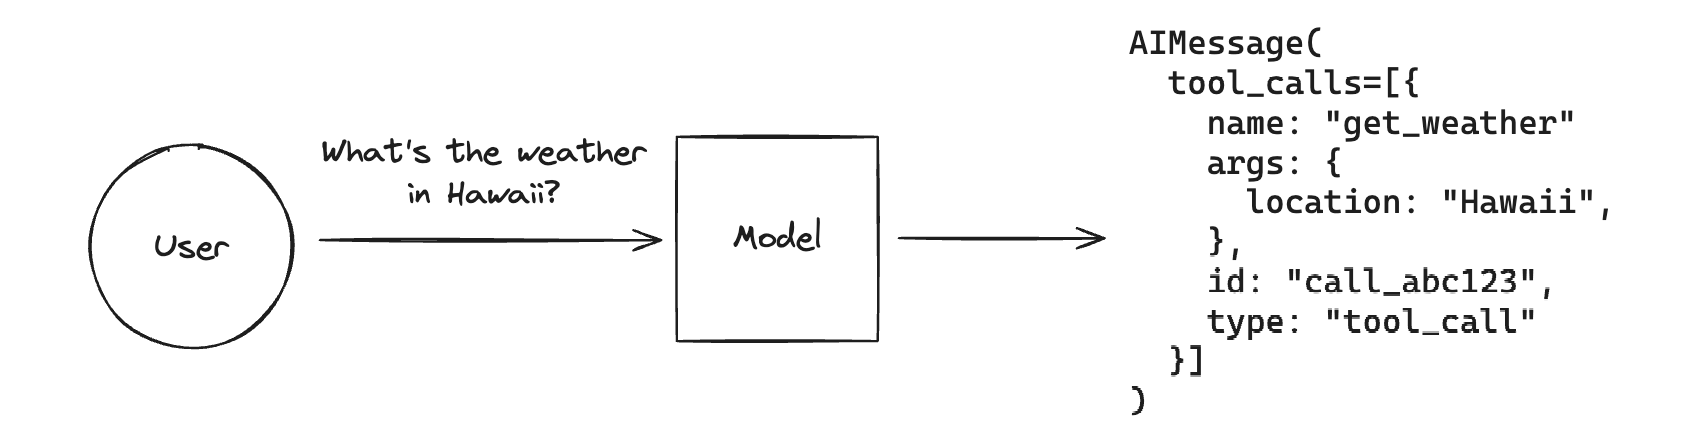

- Chat models that support tool calling features implement a .bind_tools() method for passing tool schemas to the model.

In [12]:
from dotenv import load_dotenv

load_dotenv()

True

In [13]:
from langchain_ollama import ChatOllama 
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough 
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOllama(model='llama3.2:3b', base_url='http://localhost:11434')
llm.invoke('hi')

AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2025-10-13T10:37:48.699824Z', 'done': True, 'done_reason': 'stop', 'total_duration': 253884959, 'load_duration': 92776000, 'prompt_eval_count': 26, 'prompt_eval_duration': 70408875, 'eval_count': 8, 'eval_duration': 85650541, 'message': Message(role='assistant', content='', images=None, tool_calls=None)}, id='run--ea7932cd-6ecb-4896-b6f0-6332f8104af0-0', usage_metadata={'input_tokens': 26, 'output_tokens': 8, 'total_tokens': 34})

### Custom Tools

In [14]:
### Tool Creation

from langchain_core.tools import tool

@tool
def add(a, b):
    """
    Add two integer numbers together
    
    Args:
    a: First Integer
    b: Second Integer
    """
    return a + b

@tool
def multiply(a, b):
    """
    Multiply two integer numbers together
    
    Args:
    a: First Integer
    b: Second Integer
    """
    return a * b




In [15]:
add.name, add.description, add.args, add.args_schema.schema()

/var/folders/gt/h26xk4g54zs14641vf7b8zzm0000gn/T/ipykernel_32927/2446820333.py:1: PydanticDeprecatedSince20: The `schema` method is deprecated; use `model_json_schema` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  add.name, add.description, add.args, add.args_schema.schema()


('add',
 'Add two integer numbers together\n\nArgs:\na: First Integer\nb: Second Integer',
 {'a': {'title': 'A'}, 'b': {'title': 'B'}},
 {'description': 'Add two integer numbers together\n\nArgs:\na: First Integer\nb: Second Integer',
  'properties': {'a': {'title': 'A'}, 'b': {'title': 'B'}},
  'required': ['a', 'b'],
  'title': 'add',
  'type': 'object'})

In [16]:
add.invoke({'a': 1, 'b': 2})

3

In [17]:
multiply.invoke({'a': 67, 'b': 2})

134

In [18]:
tools = [add, multiply]

llm_with_tools = llm.bind_tools(tools)

In [19]:
question  = "what is 1 plus 2?"
llm_with_tools.invoke(question).tool_calls

[{'name': 'add',
  'args': {'a': 1, 'b': 2},
  'id': 'f0dc34f7-1b62-4ea1-92dc-25cf723b592a',
  'type': 'tool_call'}]

In [20]:
question  = "what is 1 multiplied by 2?"
llm_with_tools.invoke(question).tool_calls

[{'name': 'multiply',
  'args': {'a': '1', 'b': '2'},
  'id': 'c8b06fd2-7dda-4f5a-842c-c116caaae174',
  'type': 'tool_call'}]

In [21]:
question  = "what is 1 multiplied by 2, also what is 11 plus 22?"
llm_with_tools.invoke(question).tool_calls

[{'name': 'multiply',
  'args': {'a': 1, 'b': 2},
  'id': '80c69dd6-0516-459e-95c7-388d522e03d7',
  'type': 'tool_call'},
 {'name': 'add',
  'args': {'a': 11, 'b': 22},
  'id': '7b854126-beb6-46e0-81c9-75a2e1cccaaf',
  'type': 'tool_call'}]

## Calling In-Built Tool 
### DuckDuckGo Search
- There are so many other paid options are also available like Tavily, Google, Bing, etc.

In [22]:
# https://python.langchain.com/docs/integrations/tools/

# !pip install -qU duckduckgo-search wikipedia xmltodict tavily-python

In [23]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

search.invoke("What is today's stock market news?")

'excel中函数TODAY（）是可以查看到当前的系统日期的，操作步骤如下： 1、打开一个excel文件： 2、选中任意一个单元格，这里以A1为例： 3、在选中的单元格中输入函数=TODAY（）： 4 … Apr 16, 2024 · 在Excel的数据处理世界中，掌握日期函数是必不可少的技能。其中，四个基础且实用的函数——Today、year、month和day，是数据分析的得力助手。让我们一起深入探索这些 … today和tomorrow前面可不可以加in,on,at或者是the？1、一般情况下是不加的。在有特定限制的时候，会加介词。 2、today和tomorrow等一系列表示时间的词可以做名词，也可以是副词，加 … Aug 8, 2023 · wish today 是一个河南的方言梗，意思类似卧槽、沃日。 来源出处 出自抖音一个河南的网红小李朝，他一口地道的河南话和接地气的视频内容受到很多人喜欢。wish today就是 … Apr 26, 2015 · what is the date today 和what day is it today 的相同点： （1）句式相同：两句都是疑问句，宾语都要前置。 （2）回答时的格式相同：回答时的格式都是It is。 扩展资料 （1） …'

### Tavily Search

In [24]:
# !pip install -qU langchain-tavily

In [25]:

from langchain_tavily import TavilySearch

search = TavilySearch(
    max_results=5,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
    # include_answer=False,
    # include_raw_content=False,
    # include_images=False,
    # include_image_descriptions=False,
    # search_depth="basic",
    # time_range="day",
    # include_domains=None,
    # exclude_domains=None
)

In [26]:
question = "what is today's stock market news?"
search.invoke({"query": question})

{'query': "what is today's stock market news?",
 'follow_up_questions': None,
 'answer': "U.S. stock markets rallied following Trump's comments downplaying China tariff threats. Tech stocks rose, and major averages rebounded slightly. Earnings season starts with financials reporting.",
 'images': [],
 'results': [{'url': 'https://www.tipranks.com/news/stock-market-news-today-10-13-25-u-s-stock-futures-rally-after-trump-plays-down-china-tariff-threat',
   'title': 'U.S. Stock Futures Rally After Trump Plays Down China Tariff Threat',
   'content': 'tipranks\ntipranks\n\n# Stock Market News Today, 10/13/25 – U.S. Stock Futures Rally After Trump Plays Down China Tariff Threat\n\nSheryl Sheth\nStock Market News Today, 10/13/25 – U.S. Stock Futures Rally After Trump Plays Down China Tariff Threat [...] Notably, the U.S. 10-year Treasury yield was down, floating near 4.06%. WTI crude oil futures were trending higher, hovering near $59.76 per barrel as of the last check. Additionally, the Gol

### Wikipedia Search

In [27]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper


wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())


question = "what is the capital of France?"
question = "What is LLM?"

print(wikipedia.invoke(question))

Page: Large language model
Summary: A large language model (LLM) is a language model trained with self-supervised machine learning on a vast amount of text, designed for natural language processing tasks, especially language generation. The largest and most capable LLMs are generative pre-trained transformers (GPTs) and provide the core capabilities of chatbots such as ChatGPT, Gemini and Claude. LLMs can be fine-tuned for specific tasks or guided by prompt engineering. These models acquire predictive power regarding syntax, semantics, and ontologies inherent in human language corpora, but they also inherit inaccuracies and biases present in the data they are trained on.
They consist of billions to trillions of parameters and operate as general-purpose sequence models, generating, summarizing, translating, and reasoning over text. LLMs represent a significant new technology in their ability to generalize across tasks with minimal task-specific supervision, enabling capabilities like co

### PubMed

- PubMed® comprises more than 35 million citations for biomedical literature from MEDLINE, life science journals, and online books. Citations may include links to full text content from PubMed Central and publisher web sites.



In [28]:
from langchain_community.tools.pubmed.tool import PubmedQueryRun

search = PubmedQueryRun()

print(search.invoke("What causes lung cancer?"))

Published: --
Title: Cdk5 Contributes to Diabetic Islet β Cell and Kidney Injury by Impairing Autophagy.
Copyright Information: © 2025 The Author(s). The FASEB Journal published by Wiley Periodicals LLC on behalf of Federation of American Societies for Experimental Biology.
Summary::
Insufficient insulin secretion due to islet β cell damage is a hallmark of diabetes mellitus. Diabetic nephropathy (DN) is a common microvascular complication of diabetes, and podocyte damage is the main cause of proteinuria in patients with DN. Over-activation of cyclin-dependent kinase 5 (Cdk5) is involved in the development of diabetes and its complications; however, the specific mechanism remains to be elucidated. The aim of this study was to investigate the role of Cdk5 in diabetic islet β cells and renal injury. Our results showed that Cdk5 expression was upregulated in diabetic mice, which induced attenuated autophagy and increased apoptosis of islet β cells, as well as decreased insulin secretion. 

### Tool Calling with LLM

In [29]:
@tool
def wikipedia_search(query):
    """
    Search wikipedia for general information.
    
    Args:
    query: The search query
    """
    
    wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    response = wikipedia.invoke(query)
    return response

@tool
def pubmed_search(query):
    """
    Search pubmed for medical and life sciences queries.
    
    Args:
    query: The search query
    """
    
    search = PubmedQueryRun()
    response = search.invoke(query)
    return response

@tool
def tavily_search(query):
    """
    Search the web for realtime and latest information.
    for examples, news, stock market, weather updates etc.
    
    Args:
    query: The search query
    """
   
    search = TavilySearch(
        max_results=5,
        search_depth="advanced",
        include_answer=True,
        include_raw_content=True,
        # include_answer=False,
        # include_raw_content=False,
        # include_images=False,
        # include_image_descriptions=False,
        # search_depth="basic",
        # time_range="day",
        # include_domains=None,
        # exclude_domains=None
    )
    response = search.invoke(query)
    return response


@tool
def multiply(a:int, b:int)->int:
    """
    Multiply two integer numbers together
    
    Args:
    a: First Integer
    b: Second Integer
    """
    return int(a) * int(b)


In [30]:
tools = [wikipedia_search, pubmed_search, tavily_search, multiply]

list_of_tools = { tool.name: tool for tool in tools }

In [31]:
list_of_tools

{'wikipedia_search': StructuredTool(name='wikipedia_search', description='Search wikipedia for general information.\n\nArgs:\nquery: The search query', args_schema=<class 'langchain_core.utils.pydantic.wikipedia_search'>, func=<function wikipedia_search at 0x15ed74720>),
 'pubmed_search': StructuredTool(name='pubmed_search', description='Search pubmed for medical and life sciences queries.\n\nArgs:\nquery: The search query', args_schema=<class 'langchain_core.utils.pydantic.pubmed_search'>, func=<function pubmed_search at 0x15f0c62a0>),
 'tavily_search': StructuredTool(name='tavily_search', description='Search the web for realtime and latest information.\nfor examples, news, stock market, weather updates etc.\n\nArgs:\nquery: The search query', args_schema=<class 'langchain_core.utils.pydantic.tavily_search'>, func=<function tavily_search at 0x15f0c6340>),
 'multiply': StructuredTool(name='multiply', description='Multiply two integer numbers together\n\nArgs:\na: First Integer\nb: Seco

In [32]:
llm_with_tools = llm.bind_tools(tools)

In [44]:
# query = "What is the latest news"
# query = "What is today's stock market news?"
# query = "What is LLM?"
query = "How to treat lung cancer?"
# query  = "what is 2 * 3?"
response = llm_with_tools.invoke(query)
print(response.tool_calls)

[{'name': 'wikipedia_search', 'args': {'query': 'lung cancer treatment'}, 'id': 'fa82d154-9c83-431a-8d46-9d823da8b034', 'type': 'tool_call'}]


### Generate Final Result with Tool Calling

In [34]:
from langchain_core.messages import HumanMessage, AIMessage

In [35]:
# query = "What is the latest news"
# query = "What is today's stock market news?"
# query = "What is LLM?"
query = "How to treat lung cancer?"
# query  = "what is 2 * 3?"

messages = [HumanMessage(query)]

tool_calls = llm_with_tools.invoke(messages)

messages.append(tool_calls)

tool_calls = tool_calls.tool_calls


In [45]:
from langchain_core.messages import HumanMessage

# query = "What is the latest news"
# query = "What is today's stock market news?"
# query = "What is LLM?"
query = "What is medicine for lung cancer?"
# query  = "what is 2 * 3?"

messages = [HumanMessage(query)]

ai_msg = llm_with_tools.invoke(messages)

messages.append(ai_msg)

In [42]:
ai_msg

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2025-10-13T10:38:21.615015Z', 'done': True, 'done_reason': 'stop', 'total_duration': 410981416, 'load_duration': 73612666, 'prompt_eval_count': 367, 'prompt_eval_duration': 61774208, 'eval_count': 21, 'eval_duration': 265725918, 'message': Message(role='assistant', content='', images=None, tool_calls=[ToolCall(function=Function(name='pubmed_search', arguments={'query': 'medicine for lung cancer'}))])}, id='run--6d94dd22-0d65-4ad3-96b8-62623ebe5b52-0', tool_calls=[{'name': 'pubmed_search', 'args': {'query': 'medicine for lung cancer'}, 'id': '6d395537-745f-4a2a-91c0-f0dc8709301d', 'type': 'tool_call'}], usage_metadata={'input_tokens': 367, 'output_tokens': 21, 'total_tokens': 388})

In [37]:
for tool_call in ai_msg.tool_calls:
    print(tool_call)

    name = tool_call['name'].lower()

    selected_tool = list_of_tools[name]

    tool_msg = selected_tool.invoke(tool_call)

    messages.append(tool_msg)

{'name': 'pubmed_search', 'args': {'query': 'medicine for lung cancer'}, 'id': '6d395537-745f-4a2a-91c0-f0dc8709301d', 'type': 'tool_call'}


In [38]:
messages

[HumanMessage(content='What is medicine for lung cancer?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2025-10-13T10:38:21.615015Z', 'done': True, 'done_reason': 'stop', 'total_duration': 410981416, 'load_duration': 73612666, 'prompt_eval_count': 367, 'prompt_eval_duration': 61774208, 'eval_count': 21, 'eval_duration': 265725918, 'message': Message(role='assistant', content='', images=None, tool_calls=[ToolCall(function=Function(name='pubmed_search', arguments={'query': 'medicine for lung cancer'}))])}, id='run--6d94dd22-0d65-4ad3-96b8-62623ebe5b52-0', tool_calls=[{'name': 'pubmed_search', 'args': {'query': 'medicine for lung cancer'}, 'id': '6d395537-745f-4a2a-91c0-f0dc8709301d', 'type': 'tool_call'}], usage_metadata={'input_tokens': 367, 'output_tokens': 21, 'total_tokens': 388}),
 ToolMessage(content='Published: --\nTitle: Cdk5 Contributes to Diabetic Islet β Cell and Kidney Injur

In [39]:
response = llm_with_tools.invoke(messages)
print(response.content)

I apologize for the detour earlier. To provide a more relevant response to your original question, I'll search for information on medications used to treat lung cancer.

Here's a summary of some common medications used to treat lung cancer:

1. **Chemotherapy**: Chemotherapy involves using drugs to kill cancer cells. Common chemotherapy agents for lung cancer include:
	* Etoposide (Vitalis)
	* Cisplatin
	* Docetaxel (Taxotere)
	* Paclitaxel (Taxol)
2. **Targeted therapy**: Targeted therapy uses medications that specifically target the molecular mechanisms driving tumor growth.
	* Erlotinib (Tarceva) for non-small cell lung cancer (NSCLC)
	* Gefitinib (Iressa) for NSCLC
	* Crizotinib (Xalkori) for ALK-positive NSCLC
3. **Immunotherapy**: Immunotherapy uses medications that stimulate the immune system to attack cancer cells.
	* Pembrolizumab (Keytruda)
	* Nivolumab (Opdivo)
	* Atezolizumab (Tecentriq)
4. **Hormone therapy**: Hormone therapy is used for lung cancer associated with hormone